<a href="https://colab.research.google.com/github/ricardoserodio/credit-risk-prediction/blob/main/credit_risk_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import files
uploaded = files.upload()

Saving credit_default.csv to credit_default.csv


In [6]:
import os
print(os.listdir())

['.config', 'credit_default.csv.csv', 'credit_default.csv', 'sample_data']


In [13]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# carregar dataset
df = pd.read_csv("credit_default.csv")

# definir target
target = "default.payment.next.month"

y = df[target]
X = df.drop(columns=[target, "ID"])

# dividir dados
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# modelo
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(max_iter=1000))
])

# treinar
model.fit(X_train, y_train)

# prever
y_pred = model.predict(X_test)

# resultados
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred))

Accuracy: 0.8077
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



In [15]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=1000,
        class_weight={0:1, 1:3}
    ))
])

In [16]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred))

Accuracy: 0.7527
              precision    recall  f1-score   support

           0       0.86      0.81      0.84      4673
           1       0.45      0.54      0.49      1327

    accuracy                           0.75      6000
   macro avg       0.66      0.68      0.66      6000
weighted avg       0.77      0.75      0.76      6000



Top fatores que aumentam risco de default:
PAY_6       -0.003219
BILL_AMT3    0.040465
BILL_AMT5    0.046496
BILL_AMT4    0.048844
PAY_4        0.055246
BILL_AMT2    0.072938
AGE          0.079157
PAY_3        0.092061
PAY_2        0.101148
PAY_0        0.600724
dtype: float64


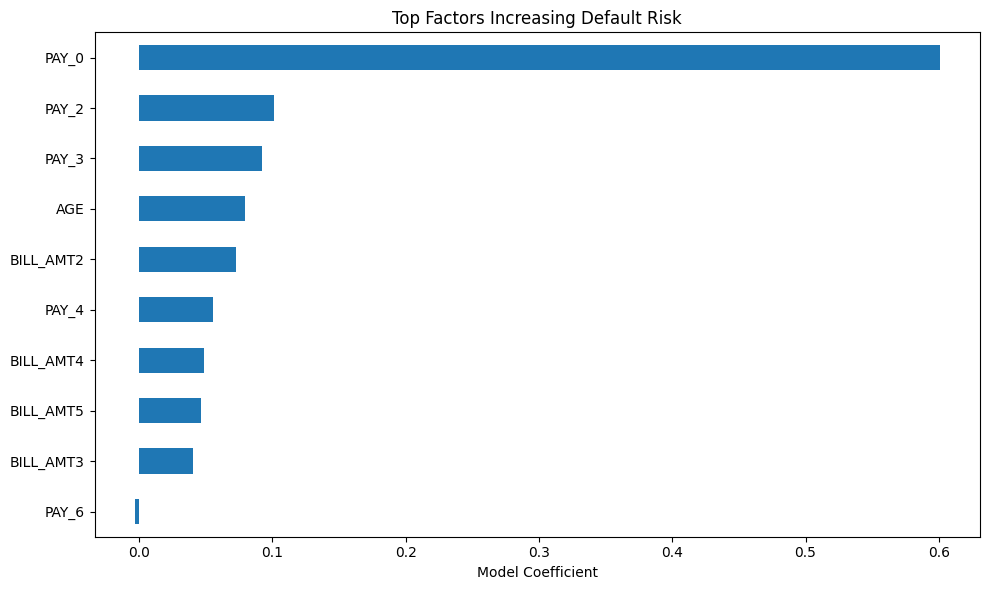

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# extrair coeficientes da logistic regression
logistic_model = model.named_steps["logistic_regression"]

importance = pd.Series(
    logistic_model.coef_[0],
    index=X.columns
).sort_values()

# mostrar fatores que mais aumentam risco
print("Top fatores que aumentam risco de default:")
print(importance.tail(10))

# gráfico
plt.figure(figsize=(10, 6))
importance.tail(10).plot(kind="barh")
plt.title("Top Factors Increasing Default Risk")
plt.xlabel("Model Coefficient")
plt.tight_layout()
plt.show()